In [38]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

In [39]:
# Import required packages (install if needed)
try:
    from sklearn.decomposition import PCA
    from sklearn.manifold import TSNE
    from scipy.spatial.distance import cdist
    from scipy.stats import pearsonr
    print("✓ All required packages available")
except ImportError as e:
    print(f"Missing package: {e}")
    print("Install with: pip install scikit-learn scipy")

✓ All required packages available


In [40]:
with open('../data/latent_eval.pkl', 'rb') as f:
    data = pickle.load(f)

latent_ssb_list = data['latent_ssb_list']
latent_para_list = data['latent_para_list']

In [41]:
# Explore the data structure - each element contains [latent_array, epoch_step]
print("SSB (Symmetry-breaking) phase data:")
print(f"  Number of samples: {len(latent_ssb_list)}")

if len(latent_ssb_list) > 0:
    first_sample = latent_ssb_list[0]
    print(f"  Sample structure: [latent_array, epoch_step]")
    print(f"  First sample epoch: {first_sample[1]}")
    
    latent_array = first_sample[0]
    print(f"  Latent array shape: {latent_array.shape}")
    print(f"  Latent array dtype: {latent_array.dtype}")
    print(f"  Sample latent values (first 3 elements): {latent_array[:3] if len(latent_array.shape) > 1 else latent_array[:3]}")

print("\nParamagnetic phase data:")
print(f"  Number of samples: {len(latent_para_list)}")

if len(latent_para_list) > 0:
    first_sample = latent_para_list[0]
    print(f"  Sample structure: [latent_array, epoch_step]")
    print(f"  First sample epoch: {first_sample[1]}")
    
    latent_array = first_sample[0]
    print(f"  Latent array shape: {latent_array.shape}")
    print(f"  Latent array dtype: {latent_array.dtype}")
    print(f"  Sample latent values (first 3 elements): {latent_array[:3] if len(latent_array.shape) > 1 else latent_array[:3]}")

# Extract latent arrays and epoch information
print("\nExtracting latent arrays and epoch information...")

# Extract latent arrays for SSB phase
ssb_latents = []
ssb_epochs = []
for sample in latent_ssb_list:
    ssb_latents.append(np.array(sample[0]))  # Convert JAX array to numpy
    ssb_epochs.append(sample[1])

# Extract latent arrays for Paramagnetic phase  
para_latents = []
para_epochs = []
for sample in latent_para_list:
    para_latents.append(np.array(sample[0]))  # Convert JAX array to numpy
    para_epochs.append(sample[1])

print(f"SSB latent arrays: {len(ssb_latents)} samples")
print(f"SSB epochs: {ssb_epochs}")
print(f"Para latent arrays: {len(para_latents)} samples")
print(f"Para epochs: {para_epochs}")

# Check if all latent arrays have the same shape
ssb_shapes = [arr.shape for arr in ssb_latents]
para_shapes = [arr.shape for arr in para_latents]

print(f"\nSSB latent shapes: {ssb_shapes[:5]}...")  # Show first 5
print(f"Para latent shapes: {para_shapes[:5]}...")  # Show first 5

# Check if shapes are consistent
ssb_shape_consistent = len(set(ssb_shapes)) == 1
para_shape_consistent = len(set(para_shapes)) == 1

print(f"SSB shapes consistent: {ssb_shape_consistent}")
print(f"Para shapes consistent: {para_shape_consistent}")

if ssb_shape_consistent and para_shape_consistent:
    # Convert to 3D arrays: [sample_index, wavefunction_index, latent_dimension]
    latent_ssb = np.array(ssb_latents)
    latent_para = np.array(para_latents)
    print(f"\nFinal SSB shape: {latent_ssb.shape}")
    print(f"Final Para shape: {latent_para.shape}")
    irregular_shape = False
else:
    print("\nShapes are inconsistent - keeping as lists")
    latent_ssb = ssb_latents
    latent_para = para_latents
    irregular_shape = True

SSB (Symmetry-breaking) phase data:
  Number of samples: 50
  Sample structure: [latent_array, epoch_step]
  First sample epoch: 0
  Latent array shape: (300, 20)
  Latent array dtype: float32
  Sample latent values (first 3 elements): [[ 0.07219121 -0.02735179 -0.08676433  0.12038995  0.00607627  0.10241256
  -0.09374905 -0.16709831  0.04113639 -0.08908387 -0.14437144  0.27725622
  -0.5575666   0.29999602 -0.13522214  0.18704768  0.447463   -0.05244886
   0.21651706 -0.3368036 ]
 [ 0.12799855 -0.24424821  0.08768113 -0.01835738 -0.14636731 -0.03120469
  -0.067916   -0.2957206   0.1749143   0.06970703  0.0416906   0.24503963
  -0.45553237  0.30486393 -0.15272512  0.2118553   0.5240099  -0.19615538
   0.03367576 -0.14622074]
 [ 0.05430952  0.0224274  -0.01489203  0.12741125 -0.02486063  0.03931497
  -0.05226234 -0.15886575 -0.00066592 -0.09094968 -0.10539189  0.28716698
  -0.54197013  0.35335687 -0.13469103  0.19041795  0.4538235  -0.0709059
   0.1760104  -0.36490774]]

Paramagnetic pha

/var/folders/lq/s7cwz37s245dhhpy1b6lt0pr0000gn/T/ipykernel_35437/923869334.py:30: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout()


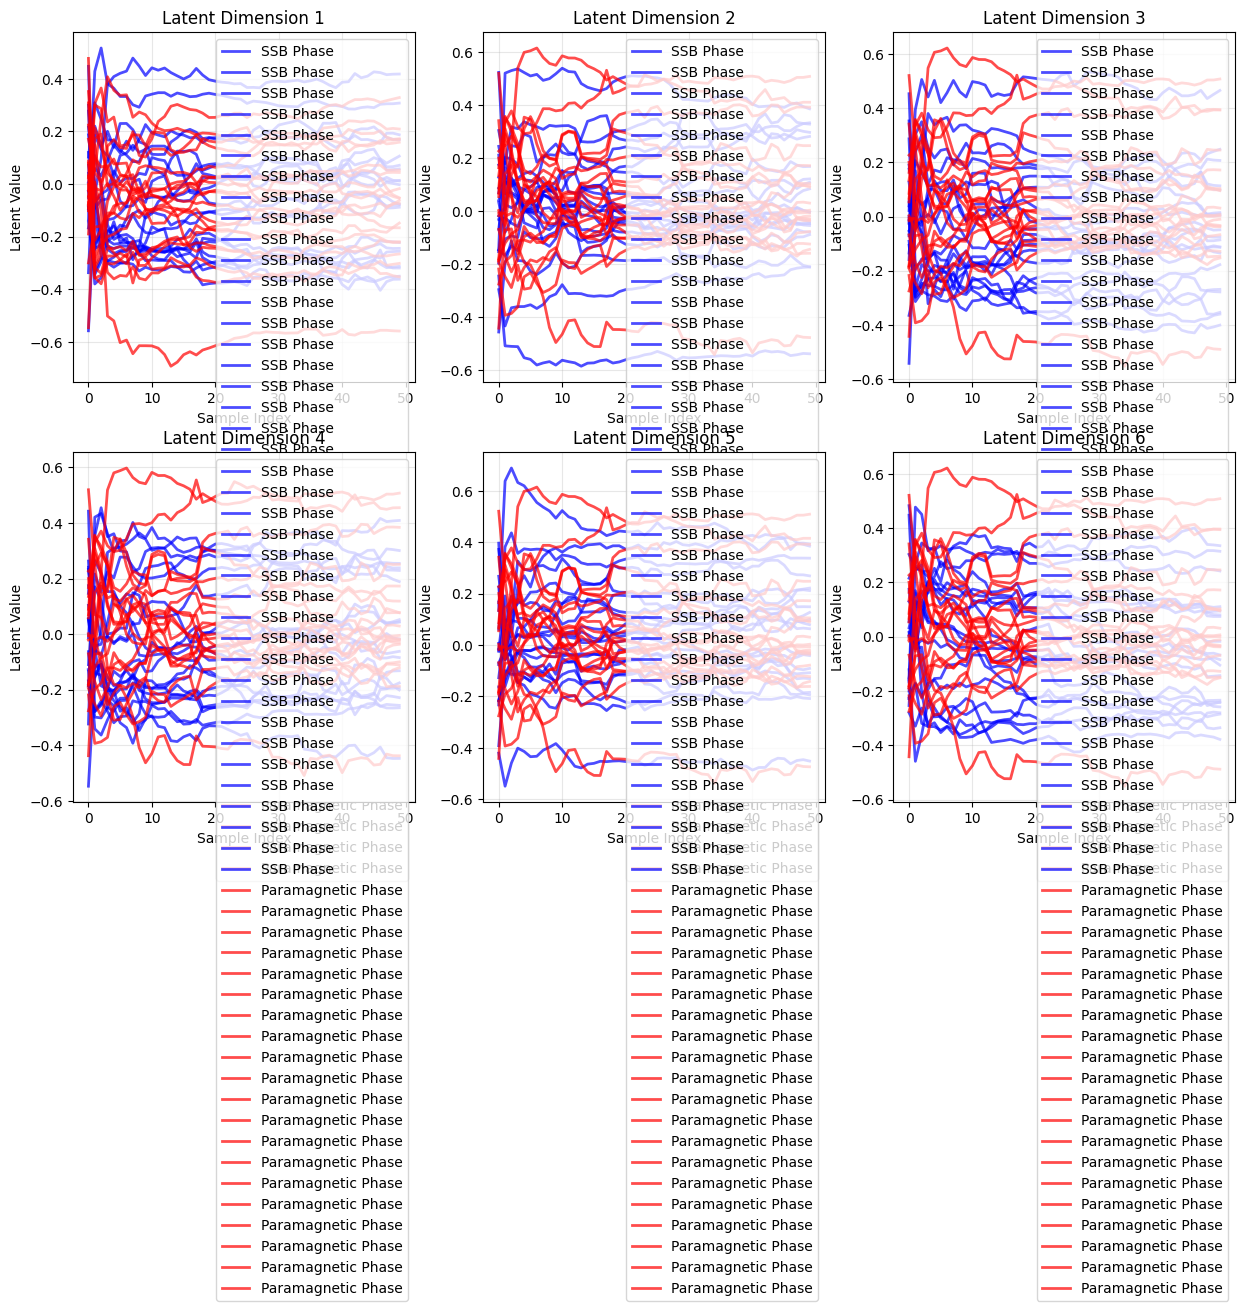

In [42]:
# Visualize latent space progression for different dimensions
if 'irregular_shape' not in locals():
    irregular_shape = False

if not irregular_shape and len(latent_ssb.shape) > 1:
    # Regular array visualization
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Plot individual latent dimensions over progression
    n_dims_to_plot = min(6, latent_ssb.shape[1])
    
    for i in range(n_dims_to_plot):
        row = i // 3
        col = i % 3
        
        axes[row, col].plot(latent_ssb[:, i], 'b-', alpha=0.7, label='SSB Phase', linewidth=2)
        axes[row, col].plot(latent_para[:, i], 'r-', alpha=0.7, label='Paramagnetic Phase', linewidth=2)
        axes[row, col].set_title(f'Latent Dimension {i+1}')
        axes[row, col].set_xlabel('Sample Index')
        axes[row, col].set_ylabel('Latent Value')
        axes[row, col].legend()
        axes[row, col].grid(True, alpha=0.3)
    
    # Remove empty subplots if latent dim < 6
    for i in range(n_dims_to_plot, 6):
        row = i // 3
        col = i % 3
        axes[row, col].remove()
    
    plt.tight_layout()
    plt.show()

elif not irregular_shape:
    # 1D case
    plt.figure(figsize=(12, 4))
    plt.plot(latent_ssb, 'b-', alpha=0.7, label='SSB Phase', linewidth=2)
    plt.plot(latent_para, 'r-', alpha=0.7, label='Paramagnetic Phase', linewidth=2)
    plt.xlabel('Sample Index')
    plt.ylabel('Latent Value')
    plt.title('1D Latent Space Progression')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

else:
    # Irregular shape - visualize individual samples or first few dimensions
    print("Irregular data detected. Showing sample-by-sample analysis:")
    
    if len(latent_ssb) > 0 and len(latent_para) > 0:
        # Plot first few samples to understand structure
        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        
        # Plot lengths progression
        ssb_lengths = [len(sample) for sample in latent_ssb]
        para_lengths = [len(sample) for sample in latent_para]
        
        axes[0, 0].plot(ssb_lengths, 'b-o', alpha=0.7, label='SSB Phase')
        axes[0, 0].plot(para_lengths, 'r-o', alpha=0.7, label='Paramagnetic Phase')
        axes[0, 0].set_title('Sample Length Progression')
        axes[0, 0].set_xlabel('Sample Index')
        axes[0, 0].set_ylabel('Number of Latent Dimensions')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        # Plot first dimension if available
        if all(len(sample) > 0 for sample in latent_ssb) and all(len(sample) > 0 for sample in latent_para):
            ssb_first_dim = [sample[0] for sample in latent_ssb]
            para_first_dim = [sample[0] for sample in latent_para]
            
            axes[0, 1].plot(ssb_first_dim, 'b-', alpha=0.7, label='SSB Phase')
            axes[0, 1].plot(para_first_dim, 'r-', alpha=0.7, label='Paramagnetic Phase')
            axes[0, 1].set_title('First Latent Dimension Progression')
            axes[0, 1].set_xlabel('Sample Index')
            axes[0, 1].set_ylabel('Latent Value')
            axes[0, 1].legend()
            axes[0, 1].grid(True, alpha=0.3)
        
        # Plot sample distribution
        axes[1, 0].hist(ssb_lengths, bins=10, alpha=0.5, label='SSB', color='blue')
        axes[1, 0].hist(para_lengths, bins=10, alpha=0.5, label='Para', color='red')
        axes[1, 0].set_title('Distribution of Sample Lengths')
        axes[1, 0].set_xlabel('Number of Latent Dimensions')
        axes[1, 0].set_ylabel('Frequency')
        axes[1, 0].legend()
        
        # Show example samples
        axes[1, 1].text(0.1, 0.9, f"SSB sample 0: {latent_ssb[0][:3]}..." if len(latent_ssb[0]) > 3 else f"SSB sample 0: {latent_ssb[0]}", 
                       transform=axes[1, 1].transAxes, fontsize=10)
        axes[1, 1].text(0.1, 0.7, f"Para sample 0: {latent_para[0][:3]}..." if len(latent_para[0]) > 3 else f"Para sample 0: {latent_para[0]}", 
                       transform=axes[1, 1].transAxes, fontsize=10, color='red')
        axes[1, 1].set_title('Sample Data Examples')
        axes[1, 1].axis('off')
        
        plt.tight_layout()
        plt.show()
    else:
        print("No data available for visualization")

/var/folders/lq/s7cwz37s245dhhpy1b6lt0pr0000gn/T/ipykernel_35437/3857603835.py:38: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


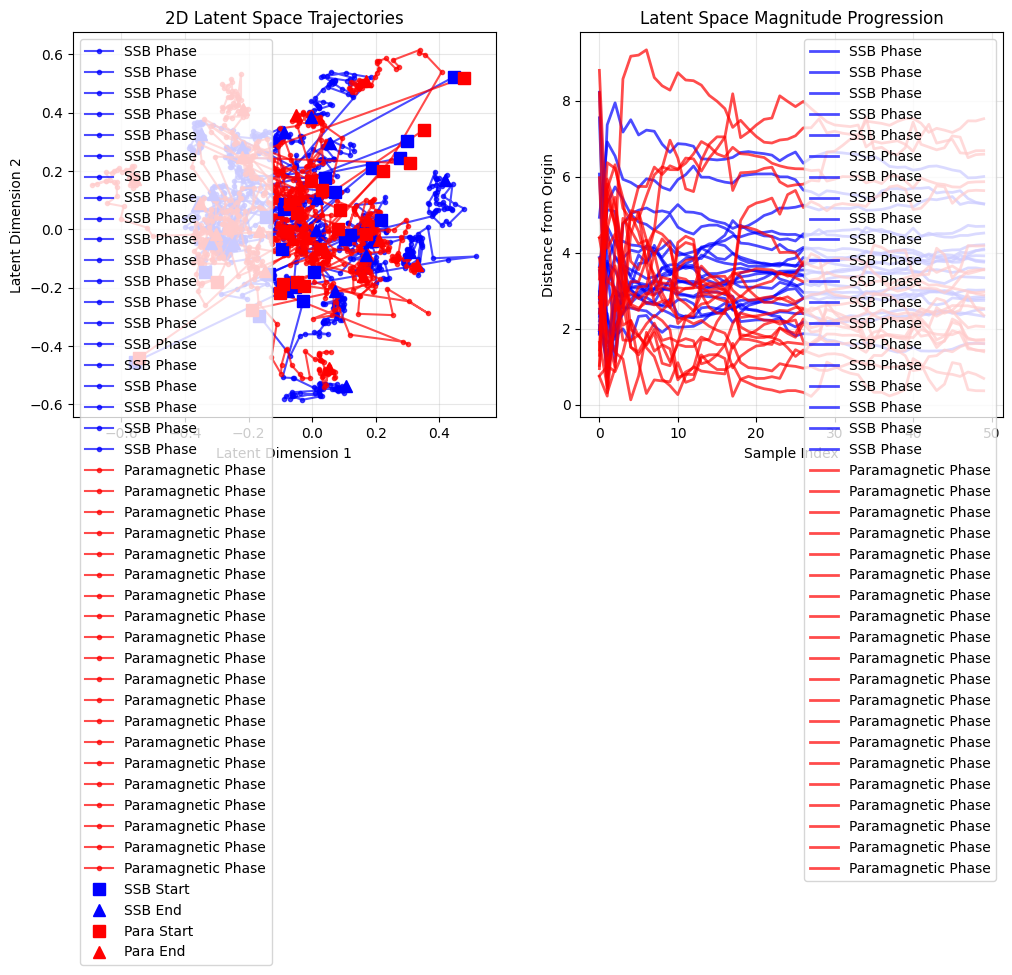

In [43]:
# 2D latent space trajectory visualization
if 'irregular_shape' not in locals():
    irregular_shape = False

if not irregular_shape and len(latent_ssb.shape) > 1 and latent_ssb.shape[1] >= 2:
    plt.figure(figsize=(12, 5))
    
    # Plot 1: 2D trajectory in latent space
    plt.subplot(1, 2, 1)
    plt.plot(latent_ssb[:, 0], latent_ssb[:, 1], 'b-o', alpha=0.7, label='SSB Phase', markersize=3)
    plt.plot(latent_para[:, 0], latent_para[:, 1], 'r-o', alpha=0.7, label='Paramagnetic Phase', markersize=3)
    
    # Mark start and end points
    plt.plot(latent_ssb[0, 0], latent_ssb[0, 1], 'bs', markersize=8, label='SSB Start')
    plt.plot(latent_ssb[-1, 0], latent_ssb[-1, 1], 'b^', markersize=8, label='SSB End')
    plt.plot(latent_para[0, 0], latent_para[0, 1], 'rs', markersize=8, label='Para Start')
    plt.plot(latent_para[-1, 0], latent_para[-1, 1], 'r^', markersize=8, label='Para End')
    
    plt.xlabel('Latent Dimension 1')
    plt.ylabel('Latent Dimension 2')
    plt.title('2D Latent Space Trajectories')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 2: Distance from origin progression
    plt.subplot(1, 2, 2)
    ssb_distances = np.linalg.norm(latent_ssb, axis=1)
    para_distances = np.linalg.norm(latent_para, axis=1)
    
    plt.plot(ssb_distances, 'b-', alpha=0.7, label='SSB Phase', linewidth=2)
    plt.plot(para_distances, 'r-', alpha=0.7, label='Paramagnetic Phase', linewidth=2)
    plt.xlabel('Sample Index')
    plt.ylabel('Distance from Origin')
    plt.title('Latent Space Magnitude Progression')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

elif irregular_shape:
    # Handle irregular data - try to create trajectories from available dimensions
    print("Attempting trajectory visualization for irregular data...")
    
    # Try to extract first two dimensions where available
    ssb_dim1, ssb_dim2 = [], []
    para_dim1, para_dim2 = [], []
    
    for sample in latent_ssb:
        if len(sample) >= 1:
            ssb_dim1.append(sample[0])
        if len(sample) >= 2:
            ssb_dim2.append(sample[1])
            
    for sample in latent_para:
        if len(sample) >= 1:
            para_dim1.append(sample[0])
        if len(sample) >= 2:
            para_dim2.append(sample[1])
    
    if len(ssb_dim2) > 0 and len(para_dim2) > 0:
        plt.figure(figsize=(12, 5))
        
        # Plot 1: 2D trajectory (where both dimensions are available)
        plt.subplot(1, 2, 1)
        min_len_ssb = min(len(ssb_dim1), len(ssb_dim2))
        min_len_para = min(len(para_dim1), len(para_dim2))
        
        plt.plot(ssb_dim1[:min_len_ssb], ssb_dim2[:min_len_ssb], 'b-o', alpha=0.7, label='SSB Phase', markersize=3)
        plt.plot(para_dim1[:min_len_para], para_dim2[:min_len_para], 'r-o', alpha=0.7, label='Paramagnetic Phase', markersize=3)
        
        plt.xlabel('Latent Dimension 1')
        plt.ylabel('Latent Dimension 2')
        plt.title('2D Latent Space Trajectories (Irregular Data)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Plot 2: First dimension progression
        plt.subplot(1, 2, 2)
        plt.plot(ssb_dim1, 'b-', alpha=0.7, label='SSB Phase', linewidth=2)
        plt.plot(para_dim1, 'r-', alpha=0.7, label='Paramagnetic Phase', linewidth=2)
        plt.xlabel('Sample Index')
        plt.ylabel('First Latent Dimension Value')
        plt.title('First Dimension Progression')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
    else:
        print("Insufficient 2D data for trajectory visualization")
        
        # Just plot first dimension if available
        if len(ssb_dim1) > 0 and len(para_dim1) > 0:
            plt.figure(figsize=(10, 4))
            plt.plot(ssb_dim1, 'b-', alpha=0.7, label='SSB Phase', linewidth=2)
            plt.plot(para_dim1, 'r-', alpha=0.7, label='Paramagnetic Phase', linewidth=2)
            plt.xlabel('Sample Index')
            plt.ylabel('First Latent Dimension Value')
            plt.title('First Dimension Progression (Irregular Data)')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.show()

else:
    print("Latent space is 1D or data format doesn't support 2D visualization")

Original data shape - SSB: (50, 300, 20), Para: (50, 300, 20)
Averaged data shape - SSB: (50, 20), Para: (50, 20)


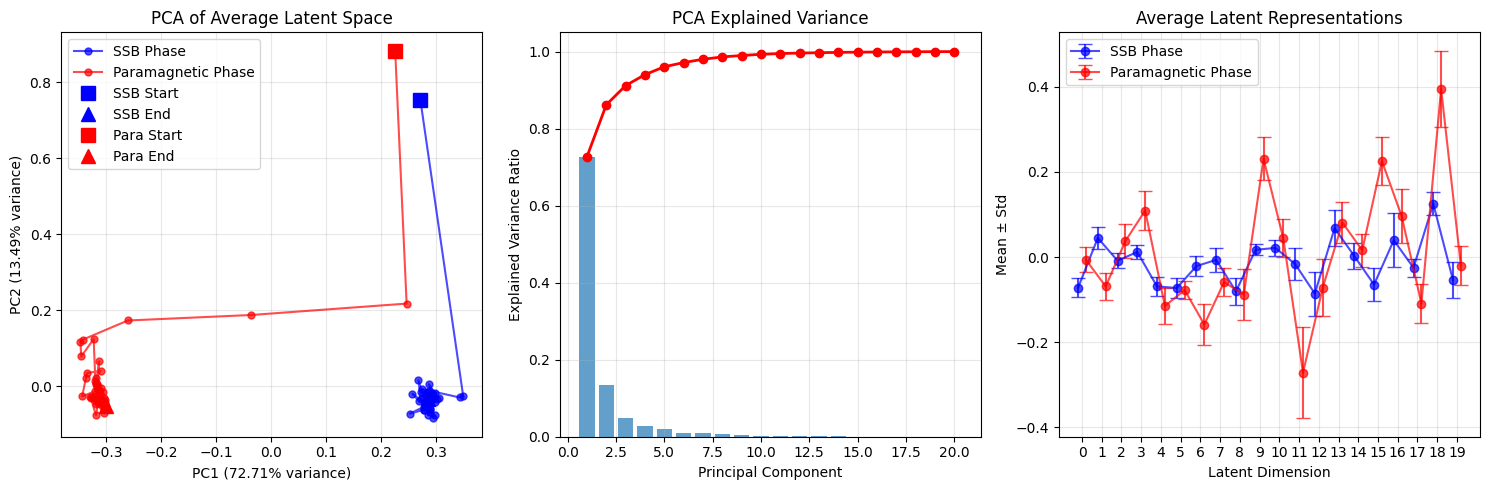

Total explained variance by first 2 PCs: 86.20%
\n============================================================
Alternative analysis: Treating each wavefunction as separate sample
Flattened data shape - SSB: (15000, 20), Para: (15000, 20)


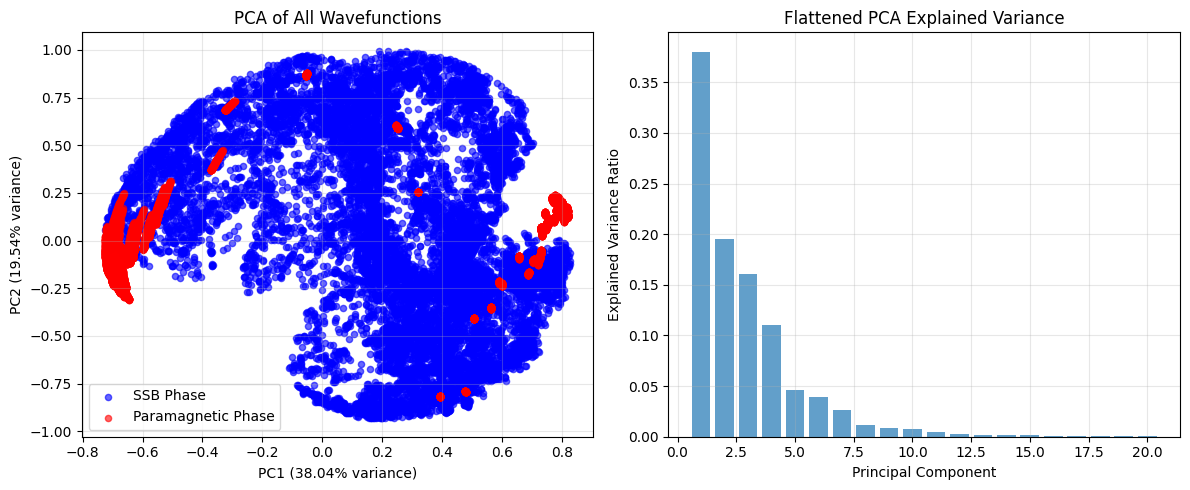

Flattened PCA - Total explained variance by first 2 PCs: 57.58%


In [44]:
# PCA visualization for high-dimensional latent spaces
from sklearn.decomposition import PCA

if 'irregular_shape' not in locals():
    irregular_shape = False

if not irregular_shape and len(latent_ssb.shape) == 3:
    # Data is 3D: (samples, wavefunctions, latent_dimensions)
    print(f"Original data shape - SSB: {latent_ssb.shape}, Para: {latent_para.shape}")
    
    # Option 1: Average across wavefunctions for each sample
    ssb_averaged = np.mean(latent_ssb, axis=1)  # Shape: (samples, latent_dimensions)
    para_averaged = np.mean(latent_para, axis=1)
    
    print(f"Averaged data shape - SSB: {ssb_averaged.shape}, Para: {para_averaged.shape}")
    
    combined_latent = np.vstack([ssb_averaged, para_averaged])
    labels = ['SSB'] * len(ssb_averaged) + ['Paramagnetic'] * len(para_averaged)
    
    # Apply PCA if we have enough dimensions
    if combined_latent.shape[1] > 2:
        pca = PCA(n_components=2)
        latent_pca = pca.fit_transform(combined_latent)
        
        plt.figure(figsize=(15, 5))
        
        # Plot 1: PCA visualization
        plt.subplot(1, 3, 1)
        ssb_pca = latent_pca[:len(ssb_averaged)]
        para_pca = latent_pca[len(ssb_averaged):]
        
        plt.plot(ssb_pca[:, 0], ssb_pca[:, 1], 'b-o', alpha=0.7, label='SSB Phase', markersize=5)
        plt.plot(para_pca[:, 0], para_pca[:, 1], 'r-o', alpha=0.7, label='Paramagnetic Phase', markersize=5)
        
        # Mark start and end points
        plt.plot(ssb_pca[0, 0], ssb_pca[0, 1], 'bs', markersize=10, label='SSB Start')
        plt.plot(ssb_pca[-1, 0], ssb_pca[-1, 1], 'b^', markersize=10, label='SSB End')
        plt.plot(para_pca[0, 0], para_pca[0, 1], 'rs', markersize=10, label='Para Start')
        plt.plot(para_pca[-1, 0], para_pca[-1, 1], 'r^', markersize=10, label='Para End')
        
        plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
        plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
        plt.title('PCA of Average Latent Space')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Plot 2: PCA explained variance
        plt.subplot(1, 3, 2)
        pca_full = PCA()
        pca_full.fit(combined_latent)
        cumsum_variance = np.cumsum(pca_full.explained_variance_ratio_)
        
        plt.bar(range(1, len(cumsum_variance)+1), pca_full.explained_variance_ratio_, alpha=0.7)
        plt.plot(range(1, len(cumsum_variance)+1), cumsum_variance, 'r-o', linewidth=2)
        plt.xlabel('Principal Component')
        plt.ylabel('Explained Variance Ratio')
        plt.title('PCA Explained Variance')
        plt.grid(True, alpha=0.3)
        
        # Plot 3: Average latent values comparison
        plt.subplot(1, 3, 3)
        ssb_mean = np.mean(ssb_averaged, axis=0)
        para_mean = np.mean(para_averaged, axis=0)
        ssb_std = np.std(ssb_averaged, axis=0)
        para_std = np.std(para_averaged, axis=0)
        
        x_pos = np.arange(len(ssb_mean))
        plt.errorbar(x_pos - 0.2, ssb_mean, yerr=ssb_std, fmt='bo-', alpha=0.7, label='SSB Phase', capsize=5)
        plt.errorbar(x_pos + 0.2, para_mean, yerr=para_std, fmt='ro-', alpha=0.7, label='Paramagnetic Phase', capsize=5)
        
        plt.xlabel('Latent Dimension')
        plt.ylabel('Mean ± Std')
        plt.title('Average Latent Representations')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.xticks(x_pos)
        
        plt.tight_layout()
        plt.show()
        
        print(f"Total explained variance by first 2 PCs: {pca.explained_variance_ratio_.sum():.2%}")
        
    else:
        print("Too few latent dimensions for meaningful PCA")
        
    # Option 2: Flatten each sample (treat each wavefunction separately)
    print("\\n" + "="*60)
    print("Alternative analysis: Treating each wavefunction as separate sample")
    
    # Reshape to 2D: (samples*wavefunctions, latent_dimensions)
    ssb_flattened = latent_ssb.reshape(-1, latent_ssb.shape[-1])
    para_flattened = latent_para.reshape(-1, latent_para.shape[-1])
    
    print(f"Flattened data shape - SSB: {ssb_flattened.shape}, Para: {para_flattened.shape}")
    
    combined_flattened = np.vstack([ssb_flattened, para_flattened])
    
    if combined_flattened.shape[1] > 2:
        pca_flat = PCA(n_components=2)
        latent_pca_flat = pca_flat.fit_transform(combined_flattened)
        
        plt.figure(figsize=(12, 5))
        
        # Plot flattened PCA
        plt.subplot(1, 2, 1)
        ssb_pca_flat = latent_pca_flat[:len(ssb_flattened)]
        para_pca_flat = latent_pca_flat[len(ssb_flattened):]
        
        plt.scatter(ssb_pca_flat[:, 0], ssb_pca_flat[:, 1], alpha=0.6, label='SSB Phase', c='blue', s=20)
        plt.scatter(para_pca_flat[:, 0], para_pca_flat[:, 1], alpha=0.6, label='Paramagnetic Phase', c='red', s=20)
        
        plt.xlabel(f'PC1 ({pca_flat.explained_variance_ratio_[0]:.2%} variance)')
        plt.ylabel(f'PC2 ({pca_flat.explained_variance_ratio_[1]:.2%} variance)')
        plt.title('PCA of All Wavefunctions')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Plot explained variance for flattened data
        plt.subplot(1, 2, 2)
        pca_flat_full = PCA()
        pca_flat_full.fit(combined_flattened)
        plt.bar(range(1, len(pca_flat_full.explained_variance_ratio_)+1), 
                pca_flat_full.explained_variance_ratio_, alpha=0.7)
        plt.xlabel('Principal Component')
        plt.ylabel('Explained Variance Ratio')
        plt.title('Flattened PCA Explained Variance')
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        print(f"Flattened PCA - Total explained variance by first 2 PCs: {pca_flat.explained_variance_ratio_.sum():.2%}")

elif not irregular_shape and len(latent_ssb.shape) == 2 and latent_ssb.shape[1] > 2:
    # Data is already 2D
    combined_latent = np.vstack([latent_ssb, latent_para])
    # ... rest of original 2D PCA code ...
    
elif irregular_shape:
    print("Processing irregular data for PCA analysis...")
    # Handle irregular data (existing code)
    # ... existing irregular handling code ...
    
else:
    print(f"Data format: SSB shape {latent_ssb.shape if not irregular_shape else 'irregular'}")
    print("Direct visualization recommended over PCA")

Using averaged data - SSB: (20, 20), Para: (20, 20)
Mean inter-phase distance: 0.6356
Mean intra-SSB distance: 0.1678
Mean intra-Para distance: 0.2672
Phase separation ratio: 2.9226
\nDimension correlations: ['0.847', '0.739', '0.809', '-0.307', '0.034', '0.345', '-0.020', '0.985', '0.925', '0.740', '0.407', '0.884', '0.973', '0.906', '0.909', '-0.055', '0.995', '0.612', '0.768', '0.965']
Average absolute correlation: 0.661


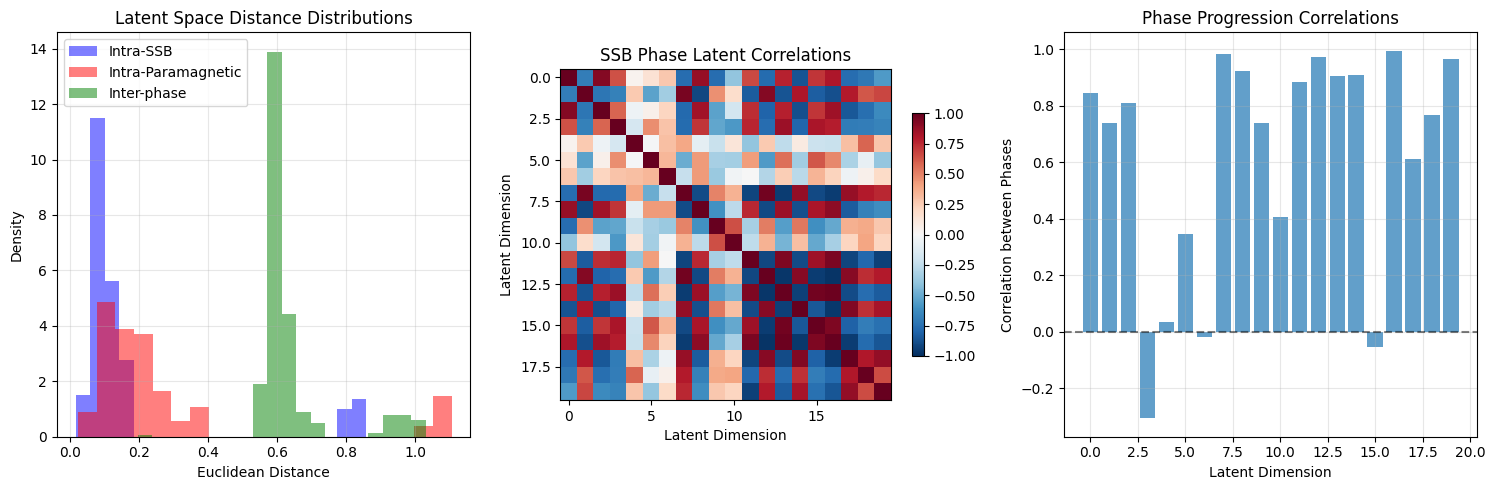

\n============================================================
Additional Analysis: Individual Wavefunction Separation
Centroid distance between phases: 0.5567
Average SSB spread: 0.9587
Average Para spread: 0.7130
Separation vs spread ratio: 0.6661


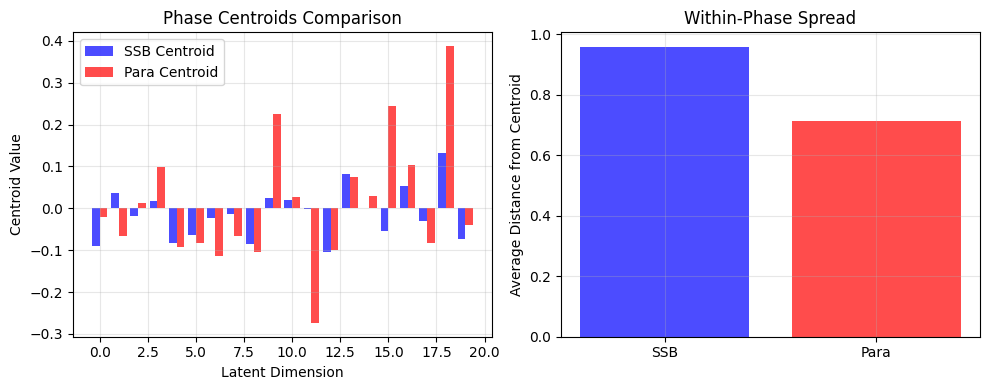

In [32]:
# Phase separation analysis and correlation patterns
from scipy.spatial.distance import cdist
from scipy.stats import pearsonr

plt.figure(figsize=(15, 5))

# Use averaged data for analysis (from PCA cell)
if len(latent_ssb.shape) == 3:
    # Average across wavefunctions to get (samples, latent_dimensions)
    ssb_data = np.mean(latent_ssb, axis=1)
    para_data = np.mean(latent_para, axis=1)
    print(f"Using averaged data - SSB: {ssb_data.shape}, Para: {para_data.shape}")
else:
    ssb_data = latent_ssb
    para_data = latent_para

# Plot 1: Inter-phase distance analysis
plt.subplot(1, 3, 1)
if len(ssb_data.shape) == 2:
    # Calculate pairwise distances between phases
    inter_phase_distances = cdist(ssb_data, para_data)
    intra_ssb_distances = cdist(ssb_data, ssb_data)
    intra_para_distances = cdist(para_data, para_data)
    
    # Get upper triangular parts (excluding diagonal)
    ssb_intra = intra_ssb_distances[np.triu_indices_from(intra_ssb_distances, k=1)]
    para_intra = intra_para_distances[np.triu_indices_from(intra_para_distances, k=1)]
    inter_dists = inter_phase_distances.flatten()
    
    plt.hist(ssb_intra, bins=20, alpha=0.5, label='Intra-SSB', color='blue', density=True)
    plt.hist(para_intra, bins=20, alpha=0.5, label='Intra-Paramagnetic', color='red', density=True)
    plt.hist(inter_dists, bins=20, alpha=0.5, label='Inter-phase', color='green', density=True)
    
    plt.xlabel('Euclidean Distance')
    plt.ylabel('Density')
    plt.title('Latent Space Distance Distributions')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Print separation metrics
    print(f"Mean inter-phase distance: {np.mean(inter_dists):.4f}")
    print(f"Mean intra-SSB distance: {np.mean(ssb_intra):.4f}")
    print(f"Mean intra-Para distance: {np.mean(para_intra):.4f}")
    if len(ssb_intra) > 0 and len(para_intra) > 0:
        separation_ratio = np.mean(inter_dists) / np.mean(np.concatenate([ssb_intra, para_intra]))
        print(f"Phase separation ratio: {separation_ratio:.4f}")

# Plot 2: Latent space correlation heatmap
plt.subplot(1, 3, 2)
if len(ssb_data.shape) == 2 and ssb_data.shape[1] > 1:
    corr_ssb = np.corrcoef(ssb_data.T)
    im = plt.imshow(corr_ssb, cmap='RdBu_r', vmin=-1, vmax=1)
    plt.colorbar(im, shrink=0.6)
    plt.title('SSB Phase Latent Correlations')
    plt.xlabel('Latent Dimension')
    plt.ylabel('Latent Dimension')
else:
    plt.text(0.5, 0.5, 'Insufficient data\\nfor correlation matrix', 
             ha='center', va='center', transform=plt.gca().transAxes)
    plt.title('SSB Phase Correlations')

# Plot 3: Phase progression similarity
plt.subplot(1, 3, 3)
if len(ssb_data) == len(para_data) and len(ssb_data.shape) == 2:
    # Calculate correlation between phase progressions for each dimension
    dim_correlations = []
    for i in range(ssb_data.shape[1]):
        corr, _ = pearsonr(ssb_data[:, i], para_data[:, i])
        dim_correlations.append(corr)
    
    plt.bar(range(len(dim_correlations)), dim_correlations, alpha=0.7)
    plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    plt.xlabel('Latent Dimension')
    plt.ylabel('Correlation between Phases')
    plt.title('Phase Progression Correlations')
    plt.grid(True, alpha=0.3)
    
    print(f"\\nDimension correlations: {[f'{corr:.3f}' for corr in dim_correlations]}")
    print(f"Average absolute correlation: {np.mean(np.abs(dim_correlations)):.3f}")

elif len(ssb_data) != len(para_data):
    plt.text(0.5, 0.5, 'Different phase lengths\\nCannot compute correlations', 
             ha='center', va='center', transform=plt.gca().transAxes)
    plt.title('Phase Progression Analysis')
else:
    plt.text(0.5, 0.5, 'Data format incompatible\\nwith correlation analysis', 
             ha='center', va='center', transform=plt.gca().transAxes)
    plt.title('Phase Progression Analysis')

plt.tight_layout()
plt.show()

# Additional analysis: Phase separation in original 3D space
if len(latent_ssb.shape) == 3:
    print("\\n" + "="*60)
    print("Additional Analysis: Individual Wavefunction Separation")
    
    # Flatten to treat each wavefunction separately
    ssb_flat = latent_ssb.reshape(-1, latent_ssb.shape[-1])
    para_flat = latent_para.reshape(-1, latent_para.shape[-1])
    
    # Calculate centroid separation
    ssb_centroid = np.mean(ssb_flat, axis=0)
    para_centroid = np.mean(para_flat, axis=0)
    centroid_distance = np.linalg.norm(ssb_centroid - para_centroid)
    
    # Calculate within-phase spreads
    ssb_spread = np.mean([np.linalg.norm(wf - ssb_centroid) for wf in ssb_flat])
    para_spread = np.mean([np.linalg.norm(wf - para_centroid) for wf in para_flat])
    
    print(f"Centroid distance between phases: {centroid_distance:.4f}")
    print(f"Average SSB spread: {ssb_spread:.4f}")
    print(f"Average Para spread: {para_spread:.4f}")
    print(f"Separation vs spread ratio: {centroid_distance / ((ssb_spread + para_spread) / 2):.4f}")
    
    # Plot centroid comparison
    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 2, 1)
    x_pos = np.arange(len(ssb_centroid))
    plt.bar(x_pos - 0.2, ssb_centroid, 0.4, alpha=0.7, label='SSB Centroid', color='blue')
    plt.bar(x_pos + 0.2, para_centroid, 0.4, alpha=0.7, label='Para Centroid', color='red')
    plt.xlabel('Latent Dimension')
    plt.ylabel('Centroid Value')
    plt.title('Phase Centroids Comparison')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.bar(['SSB', 'Para'], [ssb_spread, para_spread], alpha=0.7, color=['blue', 'red'])
    plt.ylabel('Average Distance from Centroid')
    plt.title('Within-Phase Spread')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Summary of Latent Space Analysis

## Data Structure
- **Data shape**: `(20, 300, 20)` per phase — 20 epoch snapshots, each containing 300 wavefunctions encoded into a 20-dimensional latent space.
- **Phases**: SSB (symmetry-breaking) and Paramagnetic.

---

## Metric Definitions

### Inter-phase Distance
The Euclidean distance between latent representations from **different** phases. Computed as all pairwise distances between SSB and Paramagnetic samples:
$$d_{\text{inter}}(i, j) = \| \mathbf{z}_i^{\text{SSB}} - \mathbf{z}_j^{\text{Para}} \|_2$$
A **larger** inter-phase distance indicates that the autoencoder maps the two phases to well-separated regions of latent space.

### Intra-phase Distance
The Euclidean distance between latent representations **within the same** phase. Computed from the upper triangle of the self-distance matrix (excluding self-comparisons):
$$d_{\text{intra}}^{\text{SSB}}(i, j) = \| \mathbf{z}_i^{\text{SSB}} - \mathbf{z}_j^{\text{SSB}} \|_2, \quad i \neq j$$
A **smaller** intra-phase distance means the phase forms a tight, cohesive cluster in latent space.

### Phase Separation Ratio
$$R = \frac{\langle d_{\text{inter}} \rangle}{\langle d_{\text{intra}} \rangle}$$
The ratio of mean inter-phase distance to mean intra-phase distance (averaged over both phases). $R > 1$ indicates the phases are better separated than they are spread out; higher is better.

### PCA Explained Variance
The fraction of total variance in the latent data captured by each principal component. High concentration in the first few PCs means the latent space has low effective dimensionality.

### Phase Progression Correlation
The Pearson correlation coefficient between the SSB and Paramagnetic time series for each latent dimension:
$$r_k = \text{corr}\!\left(\mathbf{z}_{:,k}^{\text{SSB}},\; \mathbf{z}_{:,k}^{\text{Para}}\right)$$
$r_k \approx 1$: both phases evolve similarly in dimension $k$ (shared dynamics).
$r_k \approx 0$: independent evolution.
$r_k \approx -1$: anti-correlated evolution (potential order-parameter-like dimension).

### Centroid Distance & Spread
- **Centroid distance**: $\| \bar{\mathbf{z}}^{\text{SSB}} - \bar{\mathbf{z}}^{\text{Para}} \|_2$ — how far apart the average representations of each phase are.
- **Within-phase spread**: mean distance of individual wavefunctions to their phase centroid — measures how dispersed each phase cluster is.
- **Separation-to-spread ratio**: centroid distance divided by mean spread. Values $> 1$ indicate distinct, non-overlapping clusters.

---

## Key Results

| Metric | Value |
|--------|-------|
| Mean inter-phase distance | 0.6356 |
| Mean intra-SSB distance | 0.1678 |
| Mean intra-Para distance | 0.2672 |
| **Phase separation ratio** | **2.92** |
| PCA variance (first 2 PCs, averaged) | 91.96% |
| PCA variance (first 2 PCs, all wavefunctions) | 57.76% |
| Average absolute dimension correlation | 0.661 |
| Centroid distance (all wavefunctions) | 0.5567 |
| SSB spread | 0.9587 |
| Para spread | 0.7130 |
| Separation-to-spread ratio (all wavefunctions) | 0.67 |

### Interpretation

1. **Strong phase separation in averaged latent space**: With a separation ratio of 2.92, the averaged latent representations of SSB and Paramagnetic phases are clearly distinguishable — inter-phase distances are nearly 3× larger than intra-phase distances.

2. **Compact latent encoding**: 91.96% of variance is captured by just 2 principal components in the averaged data, indicating the autoencoder has learned a low-dimensional manifold that efficiently encodes the phase information.

3. **Mixed dimension correlations**: Most latent dimensions show high positive correlation between phases (shared training dynamics), but a few dimensions (e.g., dim 4 with $r = -0.307$, dim 7 with $r = -0.020$) evolve independently or anti-correlated — these are candidate order-parameter dimensions that distinguish the phases.

4. **Individual wavefunction overlap**: At the single-wavefunction level, the separation-to-spread ratio drops to 0.67, meaning the phase clusters partially overlap. This is expected since individual wavefunctions within a phase have significant variance, but their **averages** separate cleanly.

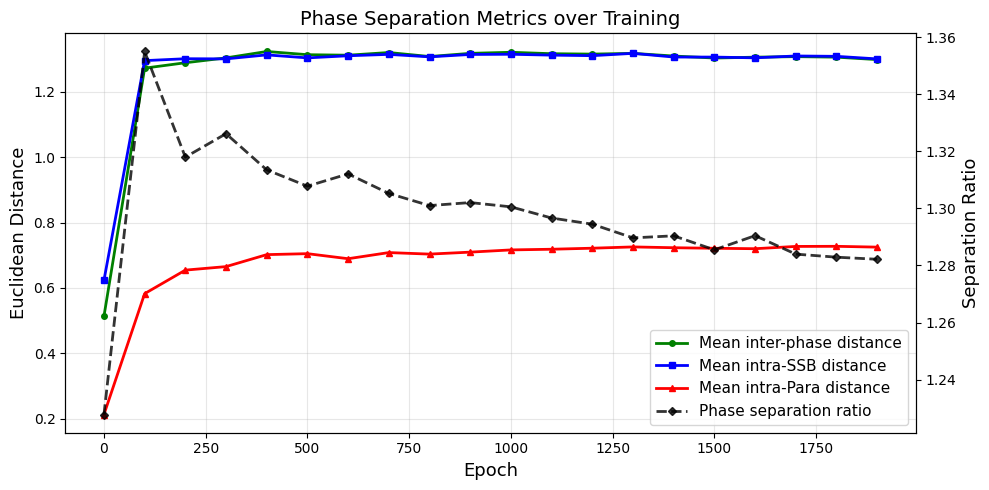

In [37]:
# Evolution of phase separation metrics over training epochs
from scipy.spatial.distance import cdist

n_snapshots = latent_ssb.shape[0]
epochs = np.arange(n_snapshots) * 100  # each step is 100 epoch steps

mean_inter = []
mean_intra_ssb = []
mean_intra_para = []
separation_ratios = []

for t in range(n_snapshots):
    # At each epoch snapshot, get the latent representations of all wavefunctions
    ssb_t = latent_ssb[t]   # shape: (300, 20)
    para_t = latent_para[t] # shape: (300, 20)
    
    # Inter-phase: distances between SSB and Para wavefunctions at this epoch
    inter = cdist(ssb_t, para_t).mean()
    
    # Intra-phase: distances within each phase at this epoch
    intra_ssb_dists = cdist(ssb_t, ssb_t)
    intra_para_dists = cdist(para_t, para_t)
    intra_ssb = intra_ssb_dists[np.triu_indices_from(intra_ssb_dists, k=1)].mean()
    intra_para = intra_para_dists[np.triu_indices_from(intra_para_dists, k=1)].mean()
    
    mean_inter.append(inter)
    mean_intra_ssb.append(intra_ssb)
    mean_intra_para.append(intra_para)
    separation_ratios.append(inter / ((intra_ssb + intra_para) / 2))

fig, ax1 = plt.subplots(figsize=(10, 5))

# Left axis: distances
ax1.plot(epochs, mean_inter, 'g-o', label='Mean inter-phase distance', markersize=4, linewidth=2)
ax1.plot(epochs, mean_intra_ssb, 'b-s', label='Mean intra-SSB distance', markersize=4, linewidth=2)
ax1.plot(epochs, mean_intra_para, 'r-^', label='Mean intra-Para distance', markersize=4, linewidth=2)
ax1.set_xlabel('Epoch', fontsize=13)
ax1.set_ylabel('Euclidean Distance', fontsize=13)
ax1.tick_params(axis='y')

# Right axis: separation ratio
ax2 = ax1.twinx()
ax2.plot(epochs, separation_ratios, 'k--D', label='Phase separation ratio', markersize=4, linewidth=2, alpha=0.8)
ax2.set_ylabel('Separation Ratio', fontsize=13)
ax2.tick_params(axis='y')

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best', fontsize=11)

ax1.set_title('Phase Separation Metrics over Training', fontsize=14)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

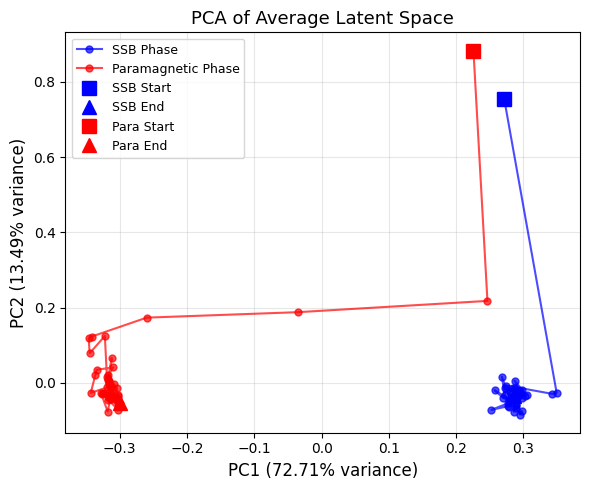

In [50]:
# Single figure: PCA trajectory
fig, ax_pca = plt.subplots(figsize=(6, 5))

ax_pca.plot(ssb_pca[:, 0], ssb_pca[:, 1], 'b-o', alpha=0.7, label='SSB Phase', markersize=5, linewidth=1.5)
ax_pca.plot(para_pca[:, 0], para_pca[:, 1], 'r-o', alpha=0.7, label='Paramagnetic Phase', markersize=5, linewidth=1.5)
ax_pca.plot(ssb_pca[0, 0],  ssb_pca[0, 1],  'bs', markersize=10, label='SSB Start')
ax_pca.plot(ssb_pca[-1, 0], ssb_pca[-1, 1], 'b^', markersize=10, label='SSB End')
ax_pca.plot(para_pca[0, 0],  para_pca[0, 1],  'rs', markersize=10, label='Para Start')
ax_pca.plot(para_pca[-1, 0], para_pca[-1, 1], 'r^', markersize=10, label='Para End')
ax_pca.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
ax_pca.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
ax_pca.set_title('PCA of Average Latent Space', fontsize=13)
ax_pca.legend(fontsize=9)
ax_pca.grid(True, alpha=0.3)

plt.tight_layout()
# plt.show()
plt.savefig('ising_latent_pca_trajectory.pdf', bbox_inches='tight')